In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
import numpy as np

import warnings
warnings.filterwarnings("ignore")

# Time Series

**Plan**

1. Intro: what is a `Time Series`?
2. Why are standard ML tools not sufficient?
3. Concept: **Decomposition**
4. Concept: **Stationarity**
5. Concept: **Autocorrelation**
6. $\color{red}{AR}$ (Autoregressive processes)
7. $\color{blue}{MA}$ (Moving averages progresses)
8. $\color{red}{AR}$ $\color{blue}{MA}$ models
9. $\color{red}{AR}$ $\color{green}{I}$ $\color{blue}{MA}$ models
10. $\color{purple}{S}$  $\color{red}{AR}$ $\color{green}{I}$ $\color{blue}{MA}$ models
11. Additional models

## 1️⃣ Introduction

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/semi_vs_high_structured_data.png' width=600 style='margin:auto'> 


### What is a Time Series?

- A Time Series is a series of repeated observations considered within a certain time interval
- The observations are taken at equal (regular/evenly spaced) time intervals

![time-series](https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/airline_passengers.png)

Time series data examples:

* Stock prices: 💹
* Weather data: ☁️🌦️🌧️🌞
* Sales data: 💰
* Heavy machinery logging data: 🏗️
* Telemetry data: 🏎️
* User activity: 👤

### What are our goals with Time Series data?

👉 "Understand" a TS = decompose, explain the behavior of a Time Series

👉 "Forecast" = predict future values based solely on existing/past observations

### Here is our [dataset](https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/09-Time-Series/new_drugs.csv):

In [30]:
# Reading data
df = pd.read_csv('https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/09-Time-Series/new_drugs.csv')

# Converting dates to datetime objects
df['date'] = pd.to_datetime(df['date'], infer_datetime_format=True)

# Setting dates as the index
df.set_index(['date'], inplace=True)
df.index.freq = 'MS'

df

,value
date,
1991-07-01,3.526591
1991-08-01,3.180891
1991-09-01,3.252221
1991-10-01,3.611003
1991-11-01,3.565869
...,...
2008-02-01,21.654285
2008-03-01,18.264945
2008-04-01,23.107677


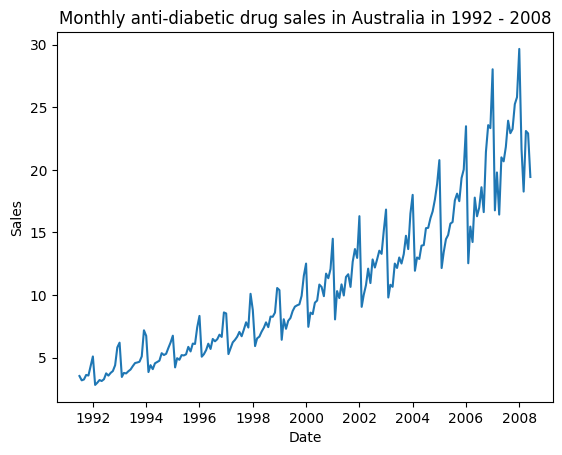

In [31]:
plt.plot(df.index, df.value)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Monthly anti-diabetic drug sales in Australia in 1992 - 2008')
plt.show()

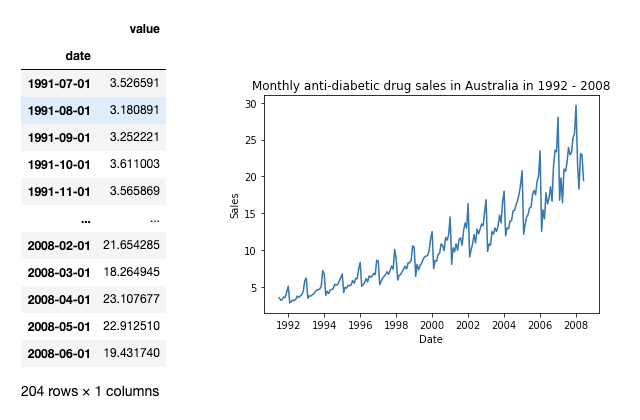

## 2️⃣. Classical ML approach to Time Series

### ❓ What is our (X, y) dataset

- `y` = `df.values`

- `X` = only information available = past `y` values

- Each row/observation is `X[t] = [y[t-1], y[t-2], ....]`

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/feature_eng_ts_annotated.png' width=600 style='margin:auto'> 


### ⚠️ `train_test_split`

<img src='https://scikit-learn.org/stable/_images/sphx_glr_plot_cv_indices_013.png'>

❌  We can't use the traditional Holdout method, a regular `train_test_split`

⚠️ It would cause  data leakage as we can't use future values to predict past values... 

✅ Contiguous `train_test_split` mandatory

In [5]:
# Let's keep the last 40% of the values out for testing purposes
train_size = 0.6
index = round(train_size*df.shape[0])

df_train = df.iloc[:index]
df_test = df.iloc[index:]

### 2.1 Predict NEXT datapoint (1-month horizon)

#### Baseline (simplest model)

- 1 feature only: `X[t] = y[t-1]`
- Predict the previous value!

In [6]:
y_pred = df_test.shift(1)
y_pred

,value
date,
2001-09-01,NaN
2001-10-01,10.647060
2001-11-01,12.652134
2001-12-01,13.674466
2002-01-01,12.965735
...,...
2008-02-01,29.665356
2008-03-01,21.654285
2008-04-01,18.264945


In [7]:
from sklearn.metrics import r2_score

y_pred = df_test.shift(1).dropna()
y_true = df_test[1:]

print(f"R2: {r2_score(y_true, y_pred)}")

R2: 0.5069517261286796


#### Linear model with 12 autoregressive features

Let's build our dataset X with 12 autoregressive features

In [8]:
df2 = df.copy(); df2_train = df_train.copy(); df2_test = df_test.copy()

for i in range(1, 13):
    df2_train[f't - {i}'] = df_train['value'].shift(i)
    df2_test[f't - {i}'] = df_test['value'].shift(i)

df2_train.dropna(inplace=True)
df2_test.dropna(inplace=True)

df2_train.head()

,value,t - 1,t - 2,t - 3,t - 4,t - 5,t - 6,t - 7,t - 8,t - 9,t - 10,t - 11,t - 12
date,,,,,,,,,,,,,
1992-07-01,3.737851,3.270523,3.127578,3.204780,2.985811,2.814520,5.088335,4.306371,3.565869,3.611003,3.252221,3.180891,3.526591
1992-08-01,3.558776,3.737851,3.270523,3.127578,3.204780,2.985811,2.814520,5.088335,4.306371,3.565869,3.611003,3.252221,3.180891
1992-09-01,3.777202,3.558776,3.737851,3.270523,3.127578,3.204780,2.985811,2.814520,5.088335,4.306371,3.565869,3.611003,3.252221
1992-10-01,3.924490,3.777202,3.558776,3.737851,3.270523,3.127578,3.204780,2.985811,2.814520,5.088335,4.306371,3.565869,3.611003
1992-11-01,4.386531,3.924490,3.777202,3.558776,3.737851,3.270523,3.127578,3.204780,2.985811,2.814520,5.088335,4.306371,3.565869


In [9]:
# Train Test Split
X2_train = df2_train.drop(columns = ['value'])
y2_train = df2_train['value']
X2_test = df2_test.drop(columns = ['value'])
y2_test = df2_test['value']

print(X2_train.shape,y2_train.shape, X2_test.shape,y2_test.shape)

(110, 12) (110,) (70, 12) (70,)


R2:  0.8580874548863758


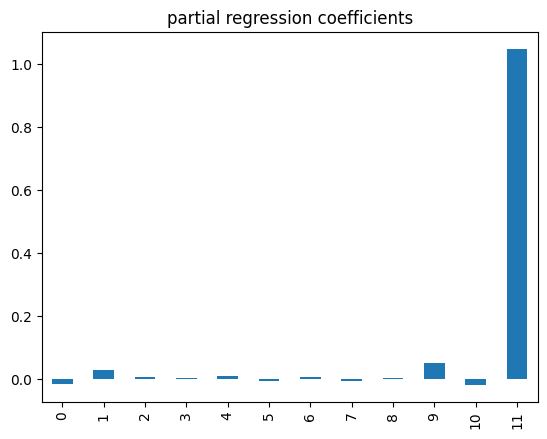

In [10]:
# Predict and measure R2
model = LinearRegression()
model = model.fit(X2_train, y2_train)

print('R2: ', r2_score(y2_test, model.predict(X2_test)))
pd.Series(model.coef_).plot(kind='bar')
plt.title('partial regression coefficients');

- Only the 12th coefficient conveys information to the model (a Linear Regression based on these 12 autoregressive features)
- Except for the 12th coefficient, most of the prediction is done by the intercept (basically predicting the mean of the last 12 values)
- All the other features are statistically insignificant (high p-values)

In [11]:
import statsmodels.api as sm

X2_1_train = sm.add_constant(X2_train)
sm_model = sm.OLS(y2_train, X2_1_train).fit()

sm_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  value   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.964
Method:                 Least Squares   F-statistic:                     240.9
Date:                Mon, 12 May 2025   Prob (F-statistic):           1.62e-66
Time:                        14:41:03   Log-Likelihood:                -63.355
No. Observations:                 110   AIC:                             152.7
Df Residuals:                      97   BIC:                             187.8
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1155      0.149      0.774      0.441      -0.181       0.412
t - 1         -0.0164      0.042     -0.390      0.697      -0.100       0.067
t - 2          0.0298      0.041      0.723      0.471      -0.052       0.112
t - 3          0.0048      0.042      0.115      0.909      -0.078       0.087
t - 4          0.0023      0.042      0.056      0.956      -0.081       0.085
t - 5          0.0091      0.042      0.217      0.829      -0.074       0.092
t - 6         -0.0055      0.042     -0.131      0.896      -0.088       0.077
t - 7          0.0057      0.045      0.126      0.900      -0.084       0.096
t - 8         -0.0073      0.050     -0.148      0.883      -0.106       0.091
t - 9          0.0043      0.050      0.086      0.932      -0.095       0.103
t - 10         0.0499      0.050      1.000      0.320      -0.049       0.149
t - 11        -0.0186      0.050     -0.373      0.710      -0.118       0.080
t - 12         1.0502      0.049     21.599      0.000       0.954       1.147
==============================================================================
Omnibus:                        6.101   Durbin-Watson:                   1.868
Prob(Omnibus):                  0.047   Jarque-Bera (JB):                9.981
Skew:                           0.021   Prob(JB):                      0.00680
Kurtosis:                       4.475   Cond. No.                         82.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### 2.2 Predict a longer time horizon?

In [12]:
# Train 1 Baseline model per forecast horizon
r2_list_single=[]

for horizon in range(1, 50):
    y_true = df_test[horizon:]
    y_pred = df_test.shift(horizon).dropna()
    r2_list_single.append(r2_score(y_true, y_pred))

In [13]:
# Train 1 LinReg with 12 features per forecast horizon
r2_list=[]

for horizon in range(1, 50):
    dfh_train = df_train.copy()
    dfh_test = df_test.copy()

    for i in range(horizon, horizon + 12):
        dfh_train[f't - {i}'] = df_train['value'].shift(i)
        dfh_test[f't - {i}'] = df_test['value'].shift(i)

    dfh_train.dropna(inplace=True)
    dfh_test.dropna(inplace=True)

    Xh_train = dfh_train.drop(columns = ['value'])
    yh_train = dfh_train['value']

    Xh_test = dfh_test.drop(columns = ['value'])
    yh_test = dfh_test['value']

    model = LinearRegression().fit(Xh_train, yh_train)
    yh_pred = model.predict(Xh_test)
    r2_list.append(r2_score(yh_test, yh_pred))

We need to train **one model per forecast horizon!**

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/time-series-horizon.png'>

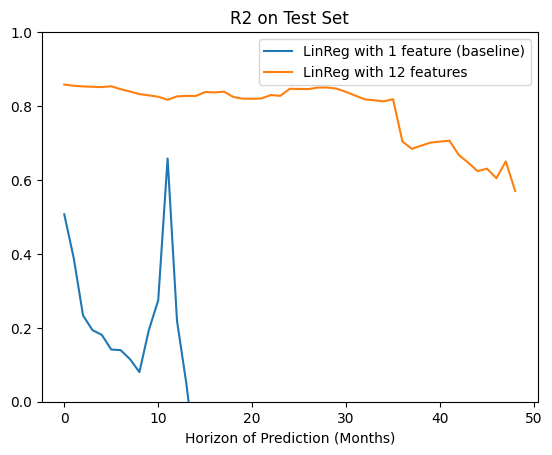

In [14]:
# Create plots
plt.plot(r2_list_single[0:50], label='LinReg with 1 feature (baseline)')
plt.plot(r2_list, label='LinReg with 12 features')

# Adjust limit on the y-axis
plt.ylim((0, 1))

# Set a title
plt.title('R2 on Test Set'); plt.xlabel('Horizon of Prediction (Months)'); plt.legend();

Results after 50 models trained!

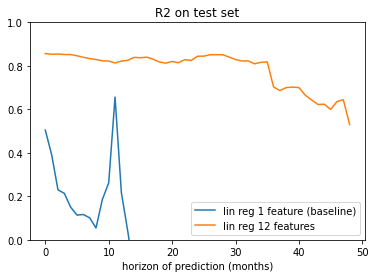

❗️ Model performance drops quickly as the horizon increases  
❓ Need to train one model per horizon?

👉 **Use tools that are specific to Time Series**

## 3️⃣. Decomposition

Most Time Series can be decomposed into several components:

1. **Trend**
2. **Seasonal** (calendar)/**Periodic** (non-calendar)
3. **Irregularities**

These components can be additive or multiplicative

How to decompose them?
- Manually (using piece-wise OLS regressions, for instance)
- Using `statsmodels.tsa`

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose

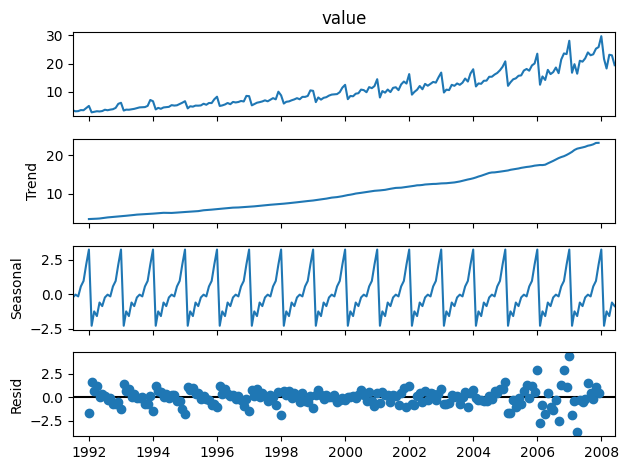

In [16]:
# Additive Decomposition (y = Trend + Seasonal + Residuals)
result_add = seasonal_decompose(df['value'], model='additive')
result_add.plot();

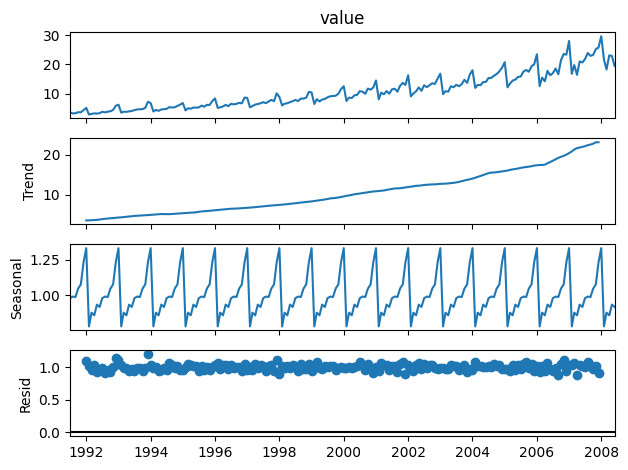

In [17]:
# Multiplicative Decomposition (y = Trend * Seasonal * Residuals)
result_mul = seasonal_decompose(df['value'], model='multiplicative')
result_mul.plot();

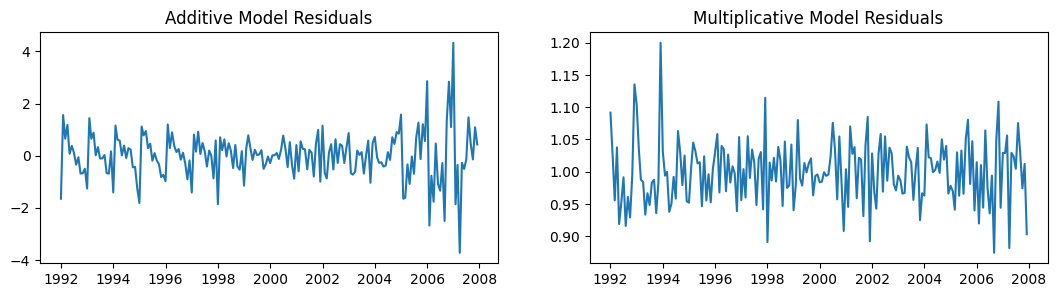

In [18]:
# Plot the residuals with "result_add.resid" to decide
f, (ax1, ax2) = plt.subplots(1,2, figsize=(13,3))
ax1.plot(result_add.resid); ax1.set_title("Additive Model Residuals")
ax2.plot(result_mul.resid); ax2.set_title("Multiplicative Model Residuals");

☝️ Multiplicative residuals seem to have **"less notion of time"** ➔ better

🤔 Why? Models work best when forecasting TS that **do not exhibit meaningful statistical changes over time** (so that we can capture these statistical properties and project/extrapolate them into the future)

In time series we call this **`stationarity`**.

✅ Most statistical forecasting methods are designed to work on **stationary Time Series**

1. **Convert** a non-stationary TS to stationary

2. **Model** our stationary TS and understand its inner working

3. **Extrapolate** that TS into the future

4. **Reintroduce** seasonality and the rest

## 4️⃣. Stationarity

🤔 When is a TS considered **stationary**?

👉 When time does not influence the statistical properties of a TS dataset, such as:
- mean
- variance
- autocorrelation (covariance with its lagged terms)

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/time_series_non_stationary.png'>

Examples of stationary and non-stationary series

![Stationarity](https://www.machinelearningplus.com/wp-content/uploads/2019/02/stationary-and-non-stationary-time-series-865x569.png?ezimgfmt=ng:webp/ngcb1)

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import scipy

def plot_stationary_ts(ar1, ar2=0, n=500, mu=0, sigma=1, show_plot=True, ymin=-10, ymax=10):
    X=np.arange(n)
    y_list = []
    y0 = 0
    y1 = 0
    for i in range(n):
        y_new = ar1 * y1 + ar2* y0 + scipy.stats.norm.rvs(mu,sigma)
        y0 = y1
        y1 = y_new.copy()
        y_list.append(y0)
    if show_plot:
        plt.figure(figsize=(20,5))
        plt.plot(X,y_list)
        plt.title(f'Autoregressive Stationary TS with Lagged Coefs = ({ar1}, {ar2})')
        plt.ylim(ymin=-10, ymax=10)
        plt.show()

    return y_list

**Stationary** TS still contain a lot of information!

When analyzing stationary data, distribution is affected only by the size of the time window, **not** the location of a time window

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/window_analysis_station.png' width=600 style='margin:auto'> 

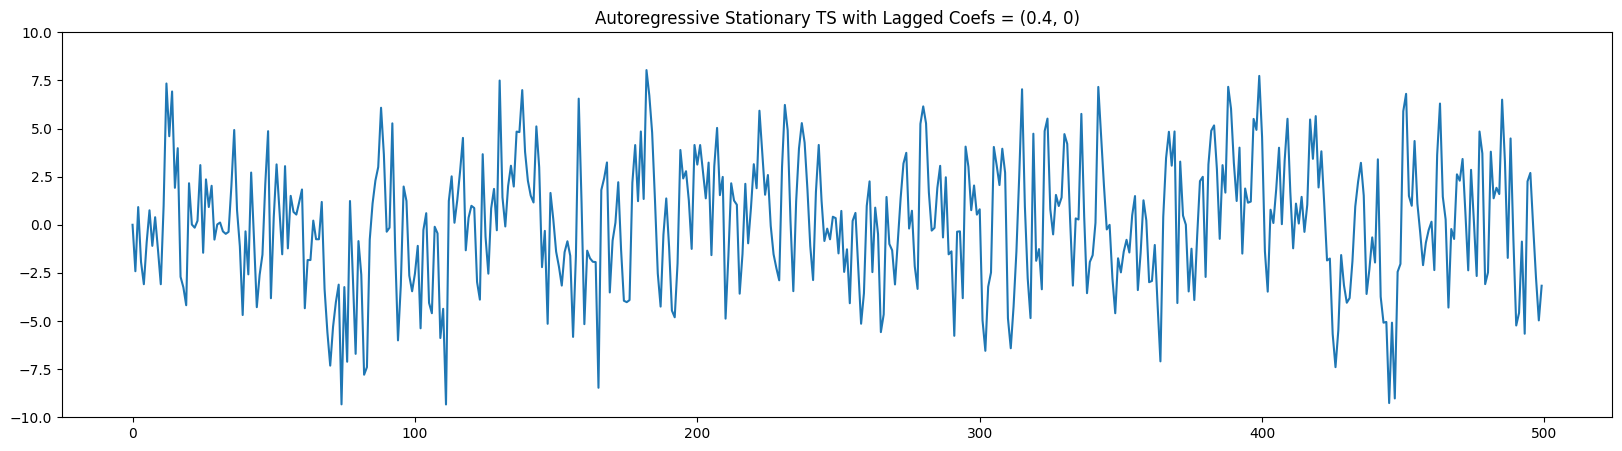

In [20]:
# Stationary TS with small autocorrelation but stronger "variance"
plot_stationary_ts(ar1=0.4, sigma=3);

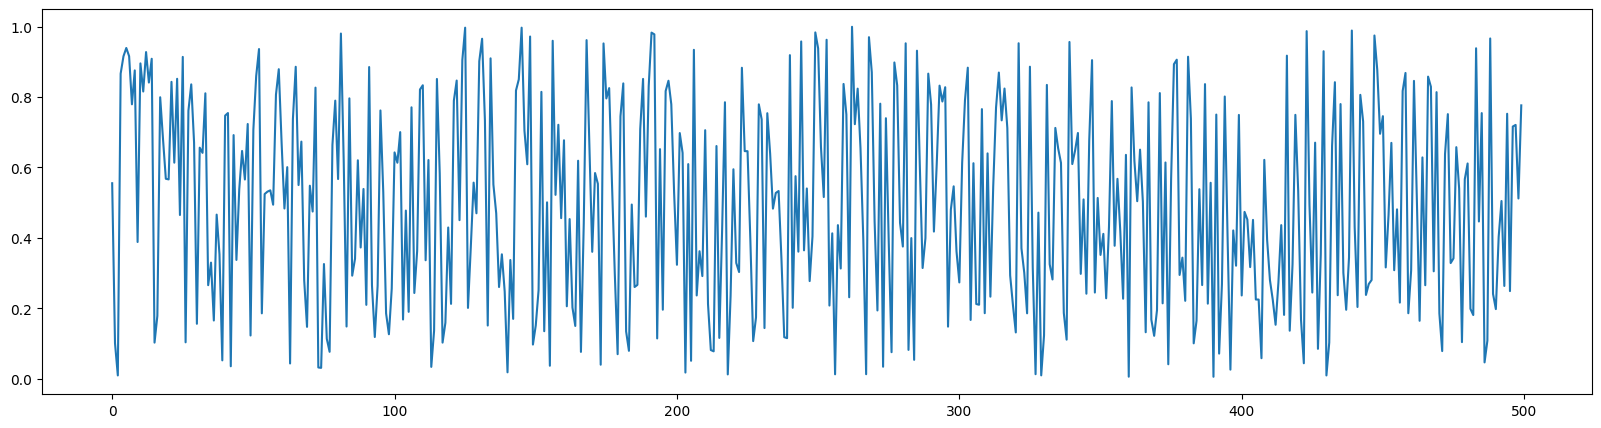

In [21]:
# White noise has no information to extract!
plt.figure(figsize=(20,5));
plt.plot(np.arange(500), [scipy.stats.uniform().rvs() for i in np.arange(500)]);

### Why is stationarity good/easier for modeling?

We will try to fit **linear models** on our time series

- Linear models are well suited for **statistical inference**

- Inference requires residuals with constant variance & mean over time   
  (no "**heteroscedasticity**")

- Inference requires **non-correlated features** and **independant samples**

👉  Hopefully, stationary time series have _constant_ autocorrelation terms that can be _managed_ by clever modeling (ARMA models)

📚 [math proof: Wold's theorem](https://en.wikipedia.org/wiki/Wold%27s_theorem)

### How do we test for stationarity?

1. Visually
2. Calculate (mean, variance, and autocorrelation) in various intervals
3. Augmented Dickey Fuller - ADF Test (p-values)

#### Augmented Dickey Fuller - ADF

ADF tests the following null hypothesis:
    
- $H_0$: The series is not-stationary
        
A `p-value` close to 0 (e.g. p < 0.05) indicates stationarity

In [22]:
from statsmodels.tsa.stattools import adfuller

adfuller(df.value)[1]  # p-value

1.0

In [23]:
print('additive resid: ', adfuller(result_add.resid.dropna())[1])
print('multiplicative resid: ', adfuller(result_mul.resid.dropna())[1])

additive resid:  0.0002852221054737728
multiplicative resid:  1.7472595795336473e-07


In [24]:
def adcf_test(df):
    print('Results of Dickey Fuller Test:')
    df_test = adfuller(df.value, autolag='AIC')
    df_output = pd.Series(df_test[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in df_test[4].items():
        df_output['Critical Value (%s)'%key] = value
    print(df_output)
adcf_test(df)

Results of Dickey Fuller Test:
Test Statistic                   3.145186
p-value                          1.000000
#Lags Used                      15.000000
Number of Observations Used    188.000000
Critical Value (1%)             -3.465620
Critical Value (5%)             -2.877040
Critical Value (10%)            -2.575032
dtype: float64


### Different ways to achieve stationarity

- Decomposition, e.g. $Y = Y_{trend} + Y_{season} + Y_{resid}$ and predict $Y_{resid}$

- Differencing, e.g. $Y_{diff} = Y_{t} - Y_{t-1}$ and predict  $Y_{diff}$

- Transformations, e.g. ($log$, $exp$, or more advanced variants)

or any combination of these three ways!

## 5️⃣. Autocorrelation

* The ACF measures the correlation between the time series $Y(t)$ and a lagged version of itself $Y(t-i)$ at different time intervals.

* The ACF at lag "k" is calculated using the following formula:

$$ ACF(k) = \frac{\sum_{t=k+1}^{n} \left(X_t-\bar{X}\right)\left(X_{t-k}-\bar{X}\right)}{\sum_{t=1}^{n}\left(X_t-\bar{X}\right)^{2}}$$

where:
* $ACF(k)$ is the autocorrelation at lag $k$
* $X_t$ is the value of the TS at time $t$

* $\bar{X}$ is the average value of the TS
* $X_{t-k}$ is the value of the time series at time $t-k$, i.e. the value of the series $k$ timesteps in the past
* $(n)$ is the total number of observations in the TS

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/auto_corr_examples.png' width=800 style='margin:auto'> 

Plot each correlation in an autocorrelation graph (ACF) below 


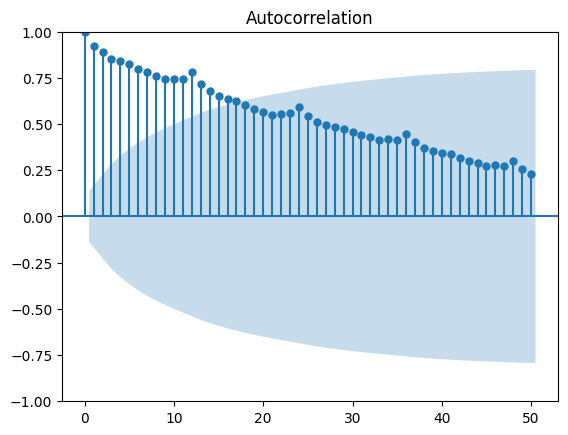

In [25]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(df.value, lags=50)
plt.show()

The blue cone represents a confidence interval (the default is 95%)

Peak inside of cone ➔ not statistically significant

🧐 What do the peaks represent?

Peaks every 12 months indicate the seasonal nature of the data - for example, the value in March 1994 will have a relatively strong correlation with the value in March 1993!

Here are a couple of examples of typical ACF plots
<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/ACF_examples.png' width=800 style='margin:auto'> 

Typically we will have a general decline in correlation between a specific time and a day further in the past; the further back in time you look, the less likely it is that that shift will have an influence

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/indirect_ACF_warning.png' width=800 style='margin:auto'> 

We have to be careful, autocorrelation doesn't just measure the **direct** effect of a lagged point in time...

...it measures the **indirect** effect **as well**!

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/indirect_direct_ACF_warning.png' width=800 style='margin:auto'> 

It can get complicated pretty quickly

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/complicated_correlation_ts.png' width=800 style='margin:auto'> 

🧐 How could we isolate the influence of a specific time lag?

## 6️⃣ $\color{red}{AR}$ (Autoregressive processes)

**We can try our Time Series as an $\color{red}{AutoRegressive (AR)}$ process!**

$$\large Y_t = \alpha + \color{red}{\beta_1} Y_{t-1} \color{black}{+} \color{red}{\beta_2} Y_{t-2} \color{black}{+ ... + } \color{red}{\beta_p} Y_{t-p} \color{black}{+} \epsilon_t $$

where $\color{red}{p}$ = <font color="red">total number of lags</font>

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/PACF_as_linear_model.png' width=800 style='margin:auto'> 

* This is a **multivariate linear regression** formula
* The **partial** correlation coefficients $\color{red}{\beta_i}$ should give us clues about the **isolated influence of specific time lags**!

Analysing the ACF for a specific time lag could be a good predictor for the current value...


We can plot each **partial** correlation coefficient $\color{red}{\beta_i}$ of the multivariate regression in a $\color{red}{PACF}$ graph.

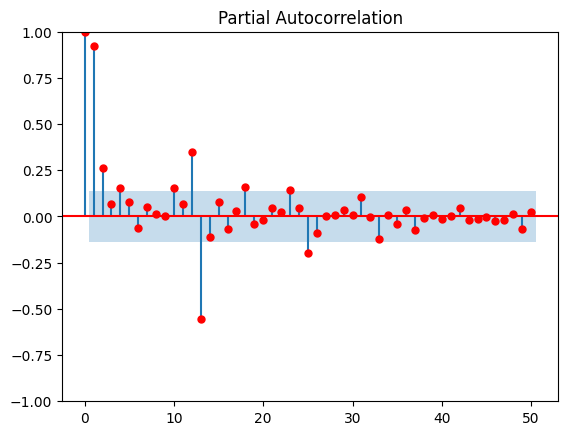

In [32]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(df.value, lags=50, c='r');

👆 Typically, we will have a much sharper decline with PACF lag values as opposed to ACF

👍 The PACF plot provides insights into the direct correlation between a specific lagged data point and the current data point, **while removing the influence of intermediate lags!**

**Side note: How do magically remove the intermediary correlations?**

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/05-ML/09-Time-Series/cheating_students.png">

* Imagine a series of students taking a test.
* The student on the left knows 100% of the answers and represents the current time point "t".
* Some students are secretly cheating by looking at their previous neighbor's test papers, but they can only see what the immediate previous student wrote.
* Think of this as the ACF - we'll see a slow decline in their test scores as we go further along (into the past).

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/05-ML/09-Time-Series/cheating_students_banned.png">

* This represents the PACF
* How much does each student **actually** know now that they can't cheat? I.e. how much is each actually correlated with t now that the intermediary correlations are taken out?

Advanced: The values for the PACF are calculated by either the Yule-Walker equations (used under the hood in StatsModels) or the Durbin-Levinson Algorithm (uses an iterative approach which is more efficient for longer time series). Both use the values provided by the ACF and assign each a coefficient that is solved for (simultaneously in the YW approach or iteratively in the DL approach).

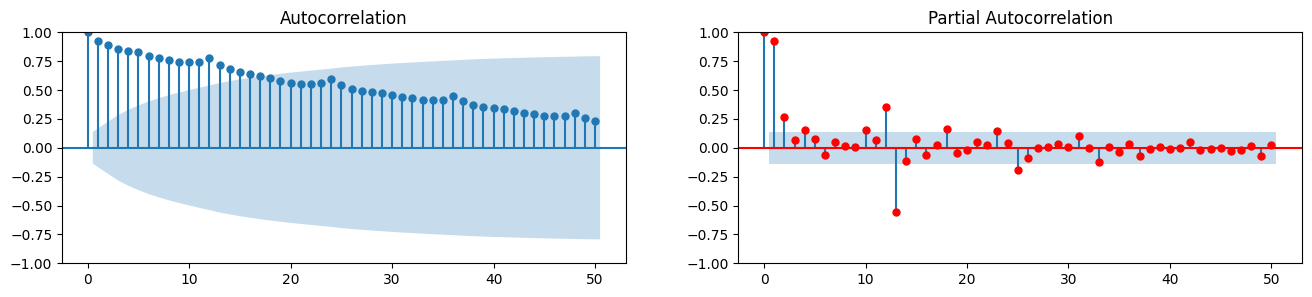

In [27]:
fig, axes = plt.subplots(1,2, figsize=(16,3))

plot_acf(df.value, lags=50, ax=axes[0]);
plot_pacf(df.value, lags=50, ax=axes[1], color='r');

- <font color=blue>ACF</font> is simply the correlation of the series with itself
    - slow exponential decrease 
    - if $X(t)$ is always correlated with $X(t-1)$, then it is also correlated with $X(t-2)$ 

- <font color=red>PACF</font> is even more informative
    - it removes intermediary correlations

👉 Annual seasonality is confirmed (peaks at `lag = 12`)

## 7️⃣ $\color{blue}{MA}$ (Moving Average processes)

Predicting the next value based on the average value of a specific window size

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/moving_average_explained.png' width=800 style='margin:auto'> 

Similar to the Auto Regressive model with PACF, we will linearly model the **errors** between our moving average predictions and the actual values



 $\large Y_t = \alpha + \color{blue}{\phi_1} \epsilon_{t-1} + \color{blue}{\phi_2} \epsilon_{t-2} + \dots + \color{blue}{\phi_q} \epsilon_{t-q} + \epsilon_t $

Where q = total number of lags in the past

## 8️⃣ $\color{red}{AR}$ $\color{blue}{MA}$ models

Let's combine our two models — Auto Regressive (AR) and Moving Average — into a single model

$\color{red}{AR}\color{blue}{MA}(\color{red}{p},\;\color{blue}{q})$ 
- as a linear combination of $\color{red}{p}$ lags of Y
- _plus_ a linear combination of $\color{blue}{q}$ lagged forecast errors

$$\color{red}{AR:}   \large  Y_t = \alpha + \color{red}{\beta_1} Y_{t-1} + \color{red}{\beta_2} Y_{t-2} + \dots + \color{red}{\beta_p} Y_{t-p} + \epsilon_t $$

$$\color{blue}{MA:} \large Y_t = \alpha + \color{blue}{\phi_1} \epsilon_{t-1} + \color{blue}{\phi_2} \epsilon_{t-2} + \dots + \color{blue}{\phi_q} \epsilon_{t-q} + \epsilon_t $$

$$ \color{red}{AR}\color{blue}{MA} \rightarrow \large{Y = \alpha + \color{red}{\beta_1} Y_{t-1} + \color{red}{\beta_2} Y_{t-2} + \dots + \color{red}{\beta_p} Y_{t-p} + + \color{blue}{\phi_1} \epsilon_{t-1} + \color{blue}{\phi_2} \epsilon_{t-2} + \dots + \color{blue}{\phi_q} \epsilon_{t-q} }  $$

Hyperparameters $\color{red}{p}$ & $\color{blue}{q}$

$\color{red}{p}$ expresses how many lags we want to incorporate into $\color{red}{AR}$

$\color{blue}{q}$ expresses how many lags we want to incorporate into $\color{blue}{MA}$

🧐 How do we know how many lags to use?

Count the number of lags before the values drop below the confidence levels
Note that the first lag is ignored, as it represents $\color{blue}{AC}$/$\color{red}{PAC}$ between $\large y_t$ and itself

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/ARMA_hyperparams.png' width=600 style='margin:auto'> 

We use the  $\color{red}{PACF}$ plot to calculate the value for $\color{red}{p}$ = $\color{red}{1}$

We use the  $\color{blue}{ACF}$ plot to calculate the value for $\color{blue}{q}$ = $\color{blue}{3}$

$\color{red}{AR}\color{blue}{MA}(\color{red}{1},\;\color{blue}{3})$ 

## 8. Auto Regressive Integrated Moving Average - ARIMA

One of the main assumptions for Time Series modeling is that the data must be **stationary**

We can apply **differencing** to our dataset to turn non-stationary data into stationary data 🎉 

We will plot the **difference between** each lag rather than the actual value for each lag

In [28]:
non_differenced_data = pd.Series([7, 4, 4, 6, 8, 6])
differenced_1 = non_differenced_data.diff()
print(differenced_1)

0    NaN
1   -3.0
2    0.0
3    2.0
4    2.0
5   -2.0
dtype: float64


We should keep differencing until our data gets stationary

In [29]:
print(differenced_1.diff())

0    NaN
1    NaN
2    3.0
3    2.0
4    0.0
5   -4.0
dtype: float64


For instance, here is some non-stationary data that we smoothed out using differencing (removed the function of time in our series) 💪

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/differencing_1.png' width=600 style='margin:auto'> 

$$\large{Y^{\color{green}{(d)}}_{t}}  = \alpha + \color{red}{\beta_1} Y_{t-1}^{\color{green}{(d)}} \color{black}{+ \dots + } \color{red}{\beta_p} Y_{t-p}^{\color{green}{(d)}} \color{black}{+} \color{blue}{\phi_1} \epsilon_{t-1} \color{black}{+ \dots + } \color{blue}{\phi_q}\epsilon_{t-q}$$

$\color{red}{AutoRegressive}$  $\color{green}{Integrated}$ $\color{blue}{MovingAverage}$


$\color{green}{I}$: Uses differencing to achieve stationarity (i.e. try to predict $Y_{diff}$)

$\color{red}{AR}$: Linear combination between $Y$ and lagged terms $Y_{t-i}$

$\color{blue}{MA}$: Linear combination between $Y$ and residual errors from the AR model above

### AR-I-MA intuition?

The $\color{red}{AR}$ **process** is simply a linear combination of $\color{red}{p}$ lags

$$Y_t = \alpha + \beta_1 Y_{t-1} + \beta_2 Y_{t-2} + \dots + \beta_\color{red}{p} Y_{t-\color{red}{p}} + \epsilon_t$$

- a process whose values are a direct linear combination of its past values

- **a one time "shock" will propagate far** into the future
    - ex: GDP may have $\beta_1$ close to 1, because next year's GDP can be stable year-by-year for a given country
    - if a country suddenly experiences a great boom (e.g. +7% in 2020) due to new policies...
    - ... this advance in absolute GDP may propagate far into the future

- not necessarily stationary

The $\color{blue}{MA}$ **process** is a linear combination of $\color{blue}{q}$ residuals

$$Y_t = \mu + \epsilon_t + \phi_1 \epsilon_{t-1} + \phi_2 \epsilon_{t-2} + \dots + \phi_\color{blue}{q} \epsilon_{t-\color{blue}{q}}$$
- a process whose values are a direct linear combination of its past changes

- **any "shock" will have a limited time effect**. 
    - ex: a conjectural shock (e.g. pandemic) might decrease a country's GDP by 10% in a given year
    - it may "bounce back" rapidly to normal after 2 years
    - $\phi_1, \phi_2$ non-null

- always stationary

$\color{green}{I}$: **Differencing** 👉 try to predict $Y^{\color{green}{(d)}}$ instead of $Y$

_First-order diff_: $$Y^{\color{green}{(1)}}_t = Y_{t} - Y_{t-1}$$

- ex: predicting GDP _growth_ instead of the GDP itself
- an advance in terms of GDP _growth_ may not propagate as far into the future as GDP does
- 👉  _differencing_ tends to turn AR processes into MA ones

    

### Let's get back to our initial dataset and model it with ARIMA

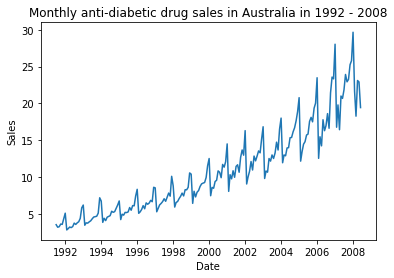

<br>
🤔 Can we make it stationary it via differencing?

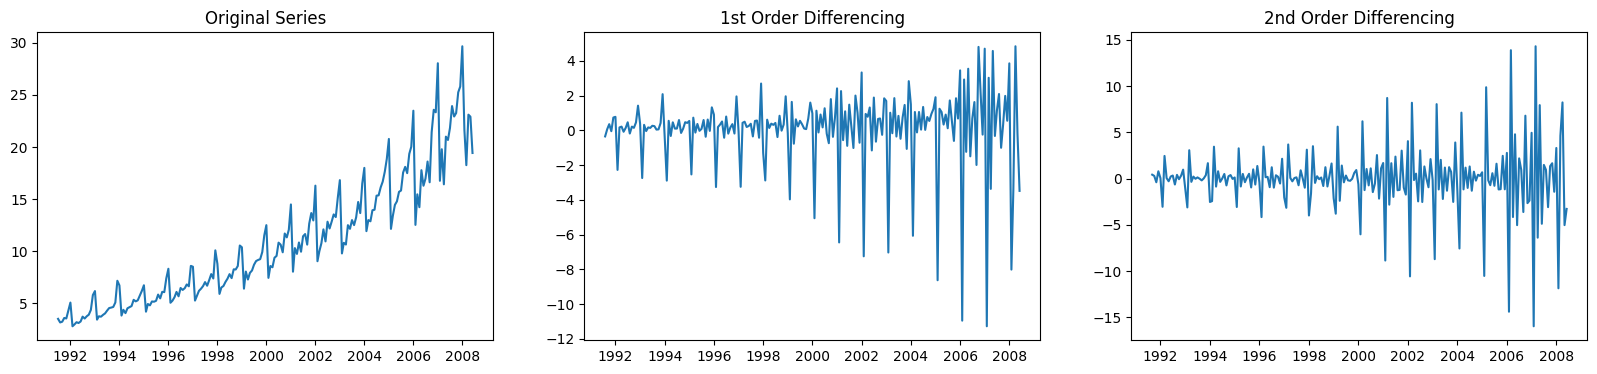

In [ ]:
zero_diff = df.value
first_order_diff = df.value.diff(1)
second_order_diff = df.value.diff(1).diff(1)


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20,4))
ax1.plot(zero_diff); ax1.set_title('Original Series')
ax2.plot(first_order_diff); ax2.set_title('1st Order Differencing')
ax3.plot(second_order_diff); ax3.set_title('2nd Order Differencing');

❌ Not stationary: seasonality is still obviously present  
❌ **Cannot apply ARIMA** directly (we will see SARIMA later)

👉 We need to *de-seasonalize* our Time Series first, using our *decomposition* tool

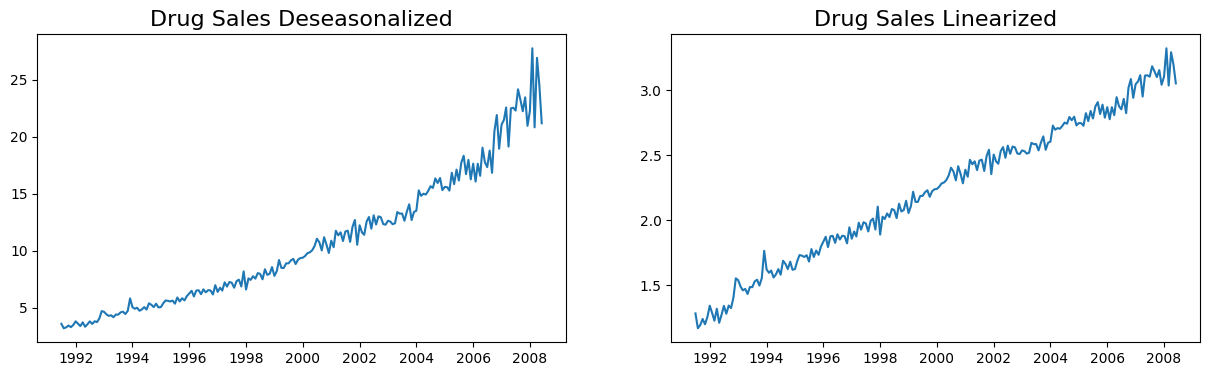

In [ ]:
# Let's remove seasons
df['deseasonalized'] = df.value.values/result_mul.seasonal

plt.figure(figsize=(15,4)); plt.subplot(1,2,1); plt.plot(df.deseasonalized);
plt.title('Drug Sales Deseasonalized', fontsize=16);

# Also remove exponential trend
df['linearized'] = np.log(df['deseasonalized'])

plt.subplot(1,2,2); plt.plot(df['linearized'])
plt.title('Drug Sales Linearized', fontsize=16);

Let's re-run our _differencing_ analysis on this new linearized Time Series

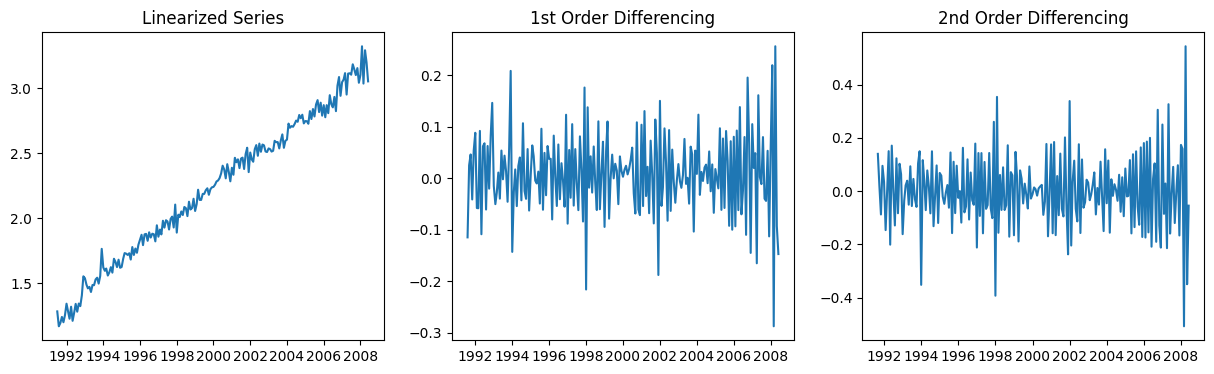

In [ ]:
# Let's difference this and look at the ACFs
fig, axes = plt.subplots(1, 3,figsize=(15,4))

axes[0].plot(df['linearized']); axes[0].set_title('Linearized Series')
# 1st Differencing
y_diff = df['linearized'].diff().dropna()
axes[1].plot(y_diff); axes[1].set_title('1st Order Differencing')

# 2nd Differencing
y_diff_diff = df['linearized'].diff().diff().dropna()
axes[2].plot(y_diff_diff); axes[2].set_title('2nd Order Differencing');

In [ ]:
# check with ADF Test for stationarity
print('p-value zero-diff: ', adfuller(df['linearized'])[1])
print('p-value first-diff: ', adfuller(df['linearized'].diff().dropna())[1])
print('p-value second-diff: ', adfuller(df['linearized'].diff().diff().dropna())[1])

p-value zero-diff:  0.7134623265852279
p-value first-diff:  1.0092820652732304e-09
p-value second-diff:  1.3181782398651779e-12


No need to over-difference

☝️ We should select $\color{green}{d}$=1 

Usually, 1-diff is enough!
If not, you might have exponential behavior and might want to use a log transformation instead!
Alternatively, we can *de-trend* and work with the *de-trended* series without differencing.

Another way to determine how many orders of differencing to apply

In [ ]:
#!pip install pmdarima

In [ ]:
# automatically estimate differencing term
from pmdarima.arima.utils import ndiffs
ndiffs(df['linearized'])

1

### Finding the hyperparameters p&q

- AR($\color{red}{p}$) ~ number of lags beyond which the $\color{red}{PACF}$ plot of $Y^{\color{green}{(d)}}$ cuts off


- MA($\color{blue}{q}$) ~ number of lags beyond which the $\color{blue}{ACF}$ plot of $Y^{\color{green}{(d)}}$ cuts off

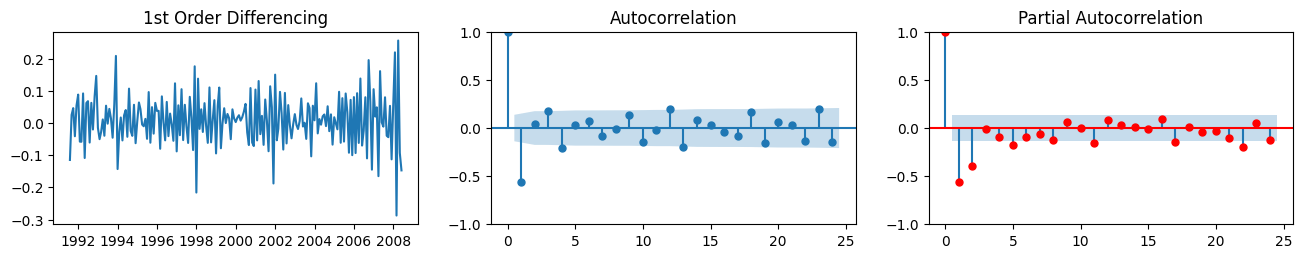

In [ ]:
# ACF / PACF analysis of y_diff linearized
fig, axes = plt.subplots(1,3, figsize=(16,2.5))
axes[0].plot(y_diff); axes[0].set_title('1st Order Differencing')
plot_acf(y_diff, ax=axes[1]);
plot_pacf(y_diff, ax=axes[2], c='r');

☝️ PACF ➔ `p` = 2  
☝️ ACF ➔ `q` = 1

$ARIMA(\color{red}{p=2},\;\color{green}{d=1},\;\color{blue}{q=1})$

☝️ More nuanced rules can be applied to hyperparameter tuning 

Use the **Box-Jenkins method**

- IMPORTANT: more than one model might explain your data.  

📚 More details can be found [here](http://people.duke.edu/~rnau/arimrule.htm) and [here](https://people.duke.edu/~rnau/411arim3.htm)

- When in doubt, choose the simpler model! 


In [ ]:
# from statsmodels.tsa.arima_model import ARIMA #statsmodels 0.11
from statsmodels.tsa.arima.model import ARIMA  #statsmodels 0.12+

arima = ARIMA(df['linearized'], order=(2, 1, 1), trend='t')
arima = arima.fit()

In [ ]:
arima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             linearized   No. Observations:                  204
Model:                 ARIMA(2, 1, 1)   Log Likelihood                 291.326
Date:                Mon, 26 Dec 2022   AIC                           -572.651
Time:                        18:08:43   BIC                           -556.085
Sample:                    07-01-1991   HQIC                          -565.949
                         - 06-01-2008                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.0097      0.001     11.599      0.000       0.008       0.011
ar.L1         -0.1424      0.095     -1.494      0.135      -0.329       0.044
ar.L2          0.0290      0.088      0.329      0.742      -0.144       0.202
ma.L1         -0.7888      0.078    -10.146      0.000      -0.941      -0.636
sigma2         0.0033      0.000     12.309      0.000       0.003       0.004
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                26.48
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               1.33   Skew:                             0.47
Prob(H) (two-sided):                  0.25   Kurtosis:                         4.50
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

###  Performance Metrics - Akaike Information Criterion

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/AIC.png' width=600 style='margin:auto'> 

We can also use **`auto_arima`** to GridSearch the hyperparameters $p$, $d$, $q$ 🥳

In [ ]:
import pmdarima as pm
smodel = pm.auto_arima(df['linearized'],
                       start_p=1, max_p=2,
                       start_q=1, max_q=2,
                       trend='t',
                       seasonal=False,
                       trace=True)

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-555.440, Time=0.24 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-453.201, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-527.228, Time=0.13 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-533.804, Time=0.16 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-453.201, Time=0.06 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-560.953, Time=0.14 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-562.744, Time=0.07 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=-562.744, Time=0.07 sec

Best model:  ARIMA(2,1,0)(0,0,0)[0] intercept
Total fit time: 0.928 seconds


⚠️ Several models have similar AIC values around -560.

Any of them might be the "true" underlying process

👉 When in doubt, pick the simplest model


$ARIMA(\color{red}{p=2},\;\color{green}{d=1},\;\color{blue}{q=0})$

### Evaluate Performance


Use `plot_predict()` to glance at our predictions

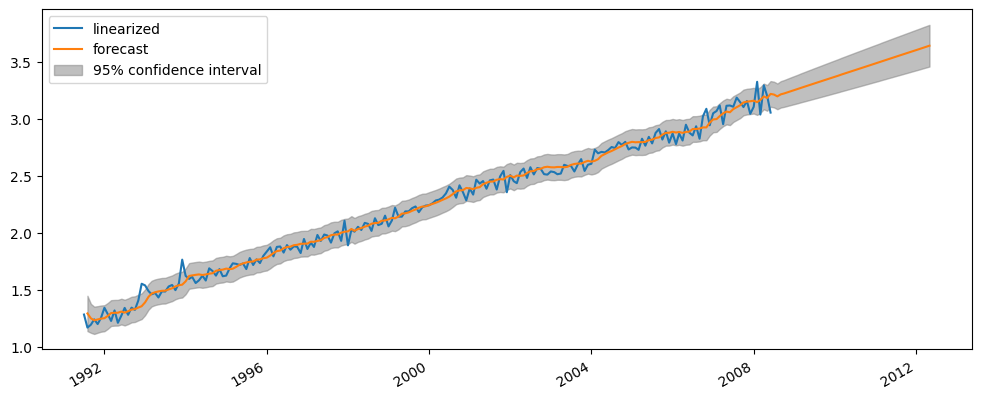

In [ ]:
from statsmodels.graphics.tsaplots import plot_predict

fig, axs = plt.subplots(1, 1, figsize=(12, 5))
axs.plot(df['linearized'], label='linearized')
plot_predict(arima, start=1, end=250, ax=axs);

Use `.forecast()` to simply access forecasts  
Use `.get_forecast()` to access forecasts and confidence intervals

In [ ]:
# Create a correct train_test_split to predict the last 50 points
train = df['linearized'][0:150]
test = df['linearized'][150:]

# Build model
arima = ARIMA(train, order=(2, 1, 0), trend='t')
arima = arima.fit()

## Forecast
# Forecast values
forecast = arima.forecast(len(test), alpha=0.05)  # 95% confidence

# Forecast values and confidence intervals
forecast_results = arima.get_forecast(len(test), alpha=0.05)
forecast = forecast_results.predicted_mean
confidence_int = forecast_results.conf_int().values

In [ ]:
# We define here a "Plot forecast vs. real", which also shows historical training set

def plot_forecast(fc, train, test, upper=None, lower=None):
    is_confidence_int = isinstance(upper, np.ndarray) and isinstance(lower, np.ndarray)
    # Prepare plot series
    fc_series = pd.Series(fc, index=test.index)
    lower_series = pd.Series(upper, index=test.index) if is_confidence_int else None
    upper_series = pd.Series(lower, index=test.index) if is_confidence_int else None

    # Plot
    plt.figure(figsize=(10,4), dpi=100)
    plt.plot(train, label='training', color='black')
    plt.plot(test, label='actual', color='black', ls='--')
    plt.plot(fc_series, label='forecast', color='orange')
    if is_confidence_int:
        plt.fill_between(lower_series.index, lower_series, upper_series, color='k', alpha=.15)
    plt.title('Forecast vs Actuals')
    plt.legend(loc='upper left', fontsize=8);

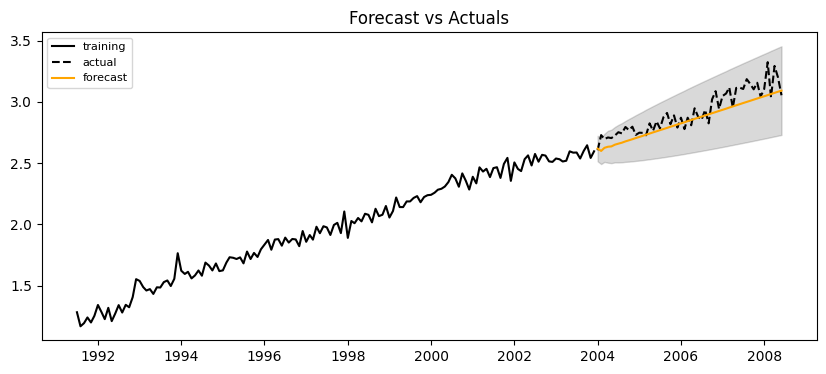

In [ ]:
plot_forecast(forecast, train, test, confidence_int[:,0], confidence_int[:,1])

⚠️Remember, this wasn't our original Time Series! 

This is the linearized version, we extracted the seasonal and exponential components.

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/recompose_ts.png'>

Let's add them back in

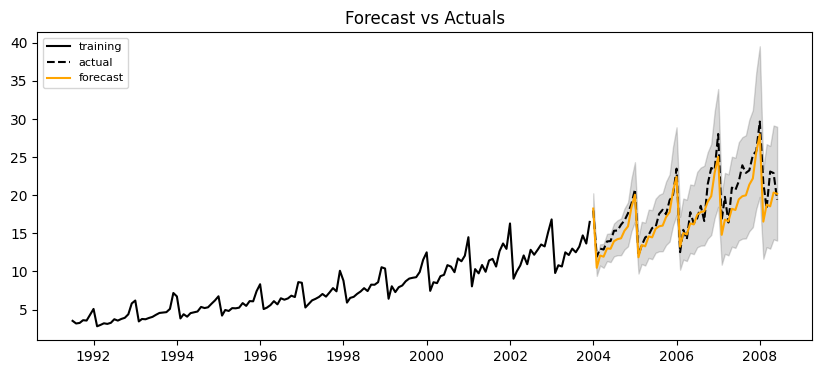

In [ ]:
# Re-compose back to initial TS

forecast_recons = np.exp(forecast) * result_mul.seasonal[150:]
train_recons = np.exp(train) * result_mul.seasonal[0:150]
test_recons = np.exp(test) * result_mul.seasonal[150:]
lower_recons = np.exp(confidence_int)[:, 0] * result_mul.seasonal[150:]
upper_recons = np.exp(confidence_int)[:, 1] * result_mul.seasonal[150:]

# Plot
plot_forecast(forecast_recons, train_recons, test_recons, lower_recons.values, upper_recons.values)

### Check residuals for inference validity

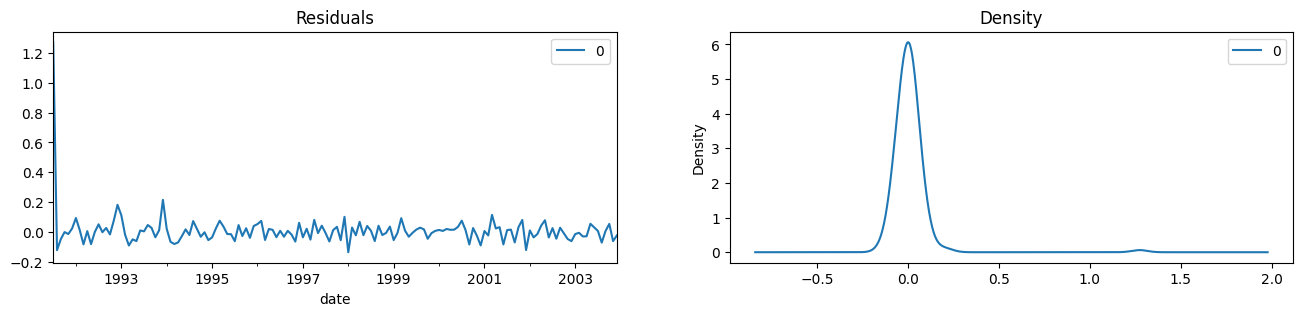

In [ ]:
residuals = pd.DataFrame(arima.resid)

fig, ax = plt.subplots(1,2, figsize=(16,3))
residuals.plot(title="Residuals", ax=ax[0])
residuals.plot(kind='kde', title='Density', ax=ax[1]);

✅ Residuals of equal variance over time (not homoscedastic)
✅ Approximately normally distributed  

👉 We can trust our "confidence interval"

### Box Jenkins Method (Summary)
<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/time_serie_process_overview.jpg'>

### Box Jenkins Method (details)

1. Apply transformations to make Time Series stationary (*de-trending*, transformations, differencing) 
2. If differencing, keep track of order `d` of differencing; don't over-difference!
3. Confirm stationarity (visually, ACF, ADF test)
4. Plot ACF/PACF, identify likely AR and MA orders `p`, `q`.
5. Fit **original** (non-differenced) data with ARIMA model of order `p`, `d`, `q`
6. Try a few other values around these orders
7. If all models with similarly low AIC, pick the least complex one
8. Inspect residuals: if ACF and PACF show white noise (no signal left) ➔ you are done. 
9. Otherwise ➔ iterate (try other transformations, change order of differencing, add/remove MA/AR terms)
10. (Optional) Compare with Auto-ARIMA output trace

Take a look at the [rules](http://people.duke.edu/~rnau/arimrule.htm) and [this](https://people.duke.edu/~rnau/411arim3.htm)

## 9. Seasonal ARIMA (SARIMA)

Removes the need to *de-seasonalize* our data

Let's plot our original Time Series one more time:

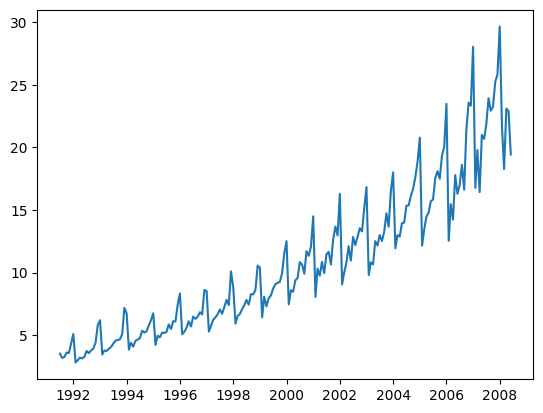

In [ ]:
plt.plot(df.value);

Where are the season windows in our data?

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/seasonal_window.png' width=500 style='margin:auto'> 

We've identified a repeating pattern within our data. The window looks like a window of size 12

This makes sense! Yearly patterns are very common

❌ Not great for stationarity

We're going to take seasonal patterns into account by modeling at the individual lag level **and** at the seasonal level

Let's use our differencing as an example of modeling at different time windows.

We'll use
$Y_{diff} = Y_t - Y_{t-k}$

* Normal differencing: $Y_{diff} = Y_t - Y_{t-k}$ ⬅ individual lag
* Seasonal differencing: $Y_{sdiff} = Y_t - Y_{t-m}$ (m=12) ⬅ 12 month lag

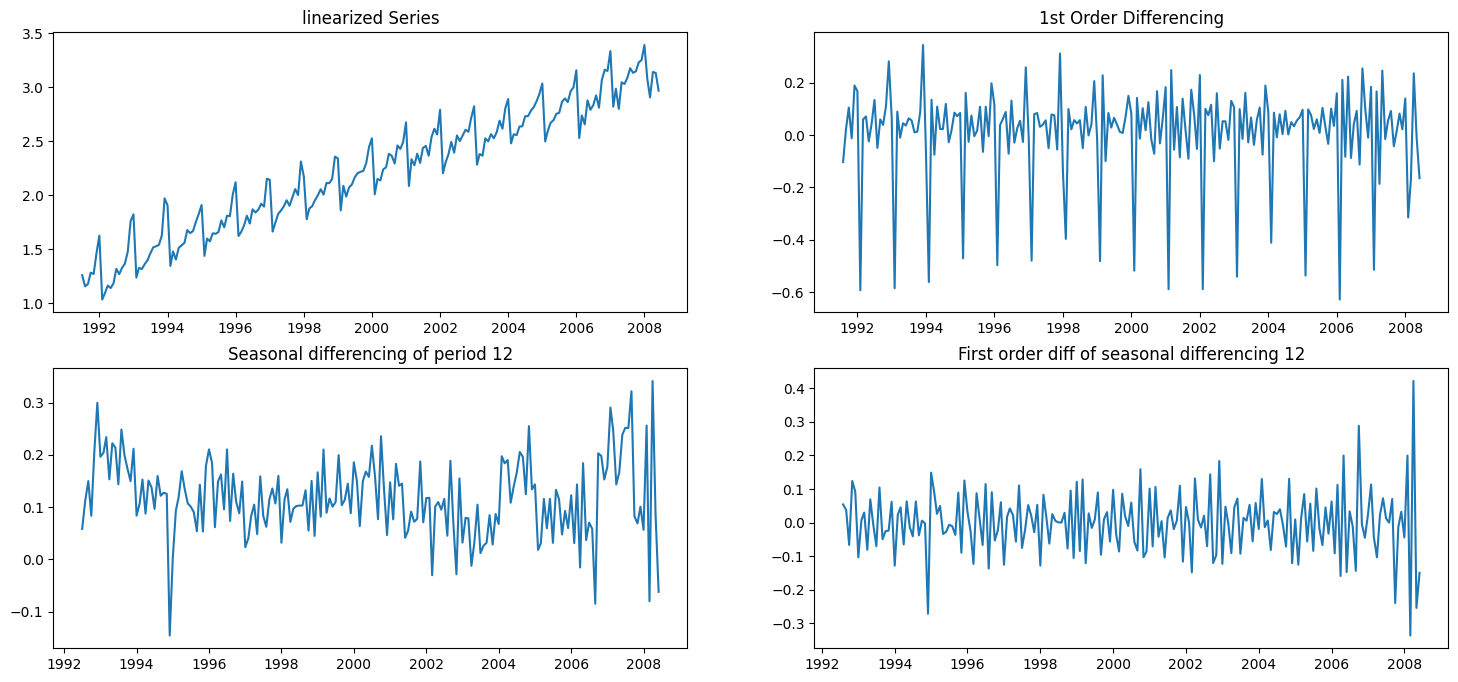

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(18,8))
# keeping just log transform to stay ~ linear
df['log'] = np.log(df.value)

# linearized series
axs[0,0].plot(df.log); axs[0,0].set_title('linearized Series')

# Normal differencing
axs[0,1].plot(df.log.diff(1)); axs[0,1].set_title('1st Order Differencing')

# Seasonal differencing
axs[1,0].plot(df.log.diff(12))
axs[1,0].set_title('Seasonal differencing of period 12')

# Sesonal + Normal differencing
axs[1,1].plot(df.log.diff(12).diff(1))
axs[1,1].set_title('First order diff of seasonal differencing 12');

Just like we applied differencing at two different lag levels, we can apply the other hyperparmeters (p and q) as well!

SARIMA has 7 hyperparameters
```python
SARIMA(p,d,q)(P,D,Q)[S]
```

_p_ ~ AR hyperparameter for individual lag level

_d_ ~ Integration hyperparameter for individual lag level

_q_ ~ MA hyperparameter for individual lag level

_P_ ~ AR hyperparameter for seasonal lag level

_D_ ~ Integration hyperparameter for seasonal lag level

_Q_ ~ MA hyperparameter for seasonal lag level


👉 **GridSearch advised**  
👉 Must only choose S manually (S = 12, for annual seasonality)

📚[Blog post on hyperparams](https://www.datasciencecentral.com/profiles/blogs/tutorial-forecasting-with-seasonal-arima)

In [ ]:
# Create a correct Training/Test split to predict the last 50 points
train = df.log[0:150]
test = df.log[150:]

In [ ]:
smodel = pm.auto_arima(train, seasonal=True, m=12,
                       start_p=0, max_p=1, max_d=1, start_q=0, max_q=1,
                       start_P=0, max_P=2, max_D=1, start_Q=0, max_Q=2,
                       trace=True, error_action='ignore', suppress_warnings=True)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=-83.662, Time=0.05 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.37 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=inf, Time=0.44 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=-85.171, Time=0.03 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.15 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=-190.471, Time=0.14 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=-315.673, Time=0.26 sec
 ARIMA(0,1,0)(2,0,1)[12] intercept   : AIC=inf, Time=0.87 sec
 ARIMA(0,1,0)(1,0,2)[12] intercept   : AIC=inf, Time=0.78 sec
 ARIMA(0,1,0)(0,0,2)[12] intercept   : AIC=inf, Time=0.38 sec
 ARIMA(0,1,0)(2,0,0)[12] intercept   : AIC=inf, Time=0.52 sec
 ARIMA(0,1,0)(2,0,2)[12] intercept   : AIC=-326.597, Time=0.97 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AIC=-366.797, Time=1.05 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : AIC=-379.829, Time=1.03 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=inf, Time=0.4

☝️ best model found
```python
SARIMAX(train, order=(0, 1, 1), seasonal_order=(2, 0, 2, 12))
```

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Build Model
sarima = SARIMAX(train, order=(0, 1, 1), seasonal_order=(2, 0, 2, 12))
sarima = sarima.fit(maxiter=75)

# Forecast
results = sarima.get_forecast(len(test), alpha=0.05)
forecast = results.predicted_mean
confidence_int = results.conf_int()

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            6     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f= -6.91380D-01    |proj g|=  4.90088D+00

At iterate    5    f= -1.31919D+00    |proj g|=  1.64744D+00


 This problem is unconstrained.



At iterate   10    f= -1.33501D+00    |proj g|=  2.50313D+00

At iterate   15    f= -1.36729D+00    |proj g|=  3.36755D-01

At iterate   20    f= -1.36779D+00    |proj g|=  8.14543D-02

At iterate   25    f= -1.37175D+00    |proj g|=  1.79727D+00

At iterate   30    f= -1.37508D+00    |proj g|=  7.95094D-03

At iterate   35    f= -1.37544D+00    |proj g|=  5.94084D-02

At iterate   40    f= -1.38871D+00    |proj g|=  8.64860D-01

At iterate   45    f= -1.39968D+00    |proj g|=  2.30724D-02

At iterate   50    f= -1.40464D+00    |proj g|=  1.62763D-01

At iterate   55    f= -1.40567D+00    |proj g|=  3.18040D-02

At iterate   60    f= -1.40580D+00    |proj g|=  3.35843D-03

At iterate   65    f= -1.40580D+00    |proj g|=  3.21205D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized 

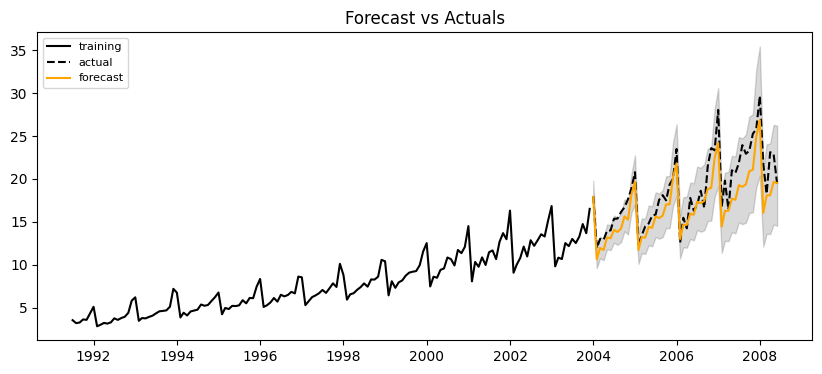

In [ ]:
# Reconstruct by taking exponential
forecast_recons = pd.Series(np.exp(forecast), index=test.index)
lower_recons = np.exp(confidence_int['lower log']).values
upper_recons = np.exp(confidence_int['upper log']).values

plot_forecast(forecast_recons, np.exp(train), np.exp(test), upper = upper_recons, lower=lower_recons)

In [ ]:
sarima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                        SARIMAX Results                                        
===============================================================================================
Dep. Variable:                                     log   No. Observations:                  150
Model:             SARIMAX(0, 1, 1)x(2, 0, [1, 2], 12)   Log Likelihood                 210.870
Date:                                 Mon, 26 Dec 2022   AIC                           -409.740
Time:                                         18:09:12   BIC                           -391.717
Sample:                                     07-01-1991   HQIC                          -402.418
                                          - 12-01-2003                                         
Covariance Type:                                   opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7951      0.063    -12.537      0.000      -0.919      -0.671
ar.S.L12       1.2124      0.093     13.101      0.000       1.031       1.394
ar.S.L24      -0.2130      0.092     -2.304      0.021      -0.394      -0.032
ma.S.L12      -0.6441      0.143     -4.520      0.000      -0.923      -0.365
ma.S.L24      -0.2543      0.135     -1.881      0.060      -0.519       0.011
sigma2         0.0026      0.000      6.925      0.000       0.002       0.003
===================================================================================
Ljung-Box (L1) (Q):                   0.07   Jarque-Bera (JB):                10.27
Prob(Q):                              0.79   Prob(JB):                         0.01
Heteroskedasticity (H):               0.75   Skew:                            -0.27
Prob(H) (two-sided):                  0.31   Kurtosis:                         4.17
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### SARIMA(X) for eXogenous features
We can take advantage of two correlated Time Series by using one to predict another

Suppose you were trying to predict the price of electricity in the next 48 hours

**_Hypothesis_**

Lower temperatures = higher electricity demand for heating = higher electricity prices

**_Therefore_**
* Using past variations of:
  * market prices (endogenous variable) ⬅ itself
  * external weather forecasts  (exogenous variable) ⬅ external Time Series
  
we can then predict the price of electricity 💪

```python
SARIMAX(engod=df['electricity_price'],
        exog=df['weather'],
        order=(3, 0, 0),seasonal_order=(0,1,2,12)
       )
```

⚠️ you need to have access to the __forecast__ values of the `exog` variable for such a model to be of any help

In [ ]:
# Let's download a 'dummy exogenous variable'
df_exog = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/a10.csv', parse_dates=['date'], index_col='date')
# Compute Seasonal Index
from dateutil.parser import parse

# multiplicative seasonal component
result_mul = seasonal_decompose(df_exog['value'][-36:],   # 3 years
                                model='multiplicative',
                                extrapolate_trend='freq')

seasonal_index = result_mul.seasonal[-12:].to_frame()
seasonal_index['month'] = pd.to_datetime(seasonal_index.index).month

# merge with the base data
df['month'] = df.index.month
df_augmented = pd.merge(df, seasonal_index, how='left', on='month')
# df_augmented.columns = ['value', 'month', 'seasonal_index']
df_augmented.index = df.index  # reassign the index.
df_augmented.drop(columns='month', inplace=True)

In [ ]:
df_augmented.head()

,value,deseasonalized,linearized,log,seasonal
date,,,,,
1991-07-01,3.526591,3.604047,1.282057,1.260332,0.970490
1991-08-01,3.180891,3.213923,1.167492,1.157161,1.050900
1991-09-01,3.252221,3.296999,1.193013,1.179338,0.998881
1991-10-01,3.611003,3.453824,1.239482,1.283986,1.059657
1991-11-01,3.565869,3.315319,1.198554,1.271408,1.146141


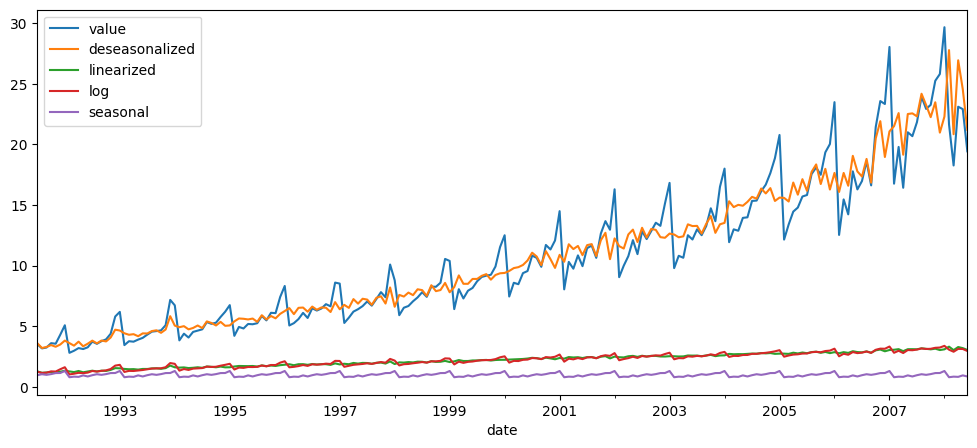

In [ ]:
df_augmented.plot(figsize=(12, 5));

In [ ]:
# Auto-fit the best SARIMAX with help from this exogenous time series
import pmdarima as pm
sarimax = pm.auto_arima(df[['value']], exogenous=df_augmented[['seasonal']],
                           start_p=0, start_q=0,
                           test='adf',
                           max_p=2, max_q=2, m=12,
                           start_P=0, seasonal=True,
                           d=None, D=1, trace=True,
                           suppress_warnings=True,
                           stepwise=True)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=625.628, Time=0.14 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=624.061, Time=0.03 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=596.068, Time=0.20 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=611.475, Time=0.17 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=757.274, Time=0.03 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=596.683, Time=0.07 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=591.868, Time=1.10 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=593.603, Time=1.32 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=0.71 sec
 ARIMA(0,0,0)(2,1,0)[12] intercept   : AIC=626.914, Time=0.79 sec
 ARIMA(2,0,0)(2,1,0)[12] intercept   : AIC=547.829, Time=1.28 sec
 ARIMA(2,0,0)(1,1,0)[12] intercept   : AIC=551.329, Time=0.34 sec
 ARIMA(2,0,0)(2,1,1)[12] intercept   : AIC=549.827, Time=1.39 sec
 ARIMA(2,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=0.78 sec
 ARIMA(2,0,1)(2,1,0)[12] intercept   : AI

In [ ]:
sarimax.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                  204
Model:             SARIMAX(2, 0, 1)x(2, 1, [], 12)   Log Likelihood                -257.707
Date:                             Mon, 26 Dec 2022   AIC                            529.414
Time:                                     18:09:34   BIC                            552.217
Sample:                                 07-01-1991   HQIC                           538.649
                                      - 06-01-2008                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0676      0.071      0.950      0.342      -0.072       0.207
ar.L1          0.6953      0.073      9.537      0.000       0.552       0.838
ar.L2          0.2739      0.068      4.026      0.000       0.141       0.407
ma.L1         -0.6340      0.063    -10.074      0.000      -0.757      -0.511
ar.S.L12      -0.4900      0.067     -7.339      0.000      -0.621      -0.359
ar.S.L24      -0.2766      0.124     -2.236      0.025      -0.519      -0.034
sigma2         0.8377      0.052     16.195      0.000       0.736       0.939
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               182.18
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):              14.89   Skew:                             0.14
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.76
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Other types of Time Series models:

- Exponential Smoothing (ETS): moving average with exponentially decaying memory of past values; great for non-linear trends with changing mean over time

- Holt's Trend-Corrected Exponential Smoothing: series has a linear trend with a slope that changes over time

- Holt-Winter's method: adds seasonality

[See more](https://otexts.com/fpp2/index.html)


## 10. (Optional) Facebook's Prophet Library 

👉 [Installation instructions](https://facebook.github.io/prophet/docs/installation.html#installation-in-python)

"Forecasting at scale" - Sean Taylor @ Facebook

Forecasting at scale is not about how many forecasts can be made or about improving the quality of forecasting

It's about giving people the power to forecast 💪

Prophet is a robust forecasting model that thrives on data with strong seasonal effects and that has several seasons of historical data 🧙‍♂️

**Pros** 👍
* Easy to implement
* Good for pure autoregressive (holidays, for example)
* Pre-coded plot methods
* Automatic cross-validation tools

**Cons** 👎
* Black-box
* Less control/performance compared to `statsmodels`

- The library uses a decomposable Time Series model with three main model components: trend, seasonality, and holidays. They are combined in the following equation:

$$y(t) = p(t) + s(t) + h(t) + ε_t$$

where:
- $p(t)$: piece-wise linear or logistic growth curve for modeling non-periodic changes in Time Series
- $s(t)$: periodic changes
- $h(t)$: effects of holidays with irregular schedules
- $ε_t$: error term accounts for any unusual changes not accommodated by the model


### Using Prophet
Prophet's ease-of-use requires the data to be structured exactly like this: a `ds` column and a `y` column

In [ ]:
# Specific format required by Prophet
df = df.reset_index().rename(columns={'date': 'ds', 'value':'y'})
df.head()

,ds,y,deseasonalized,linearized,log,month
0,1991-07-01,3.526591,3.604047,1.282057,1.260332,7
1,1991-08-01,3.180891,3.213923,1.167492,1.157161,8
2,1991-09-01,3.252221,3.296999,1.193013,1.179338,9
3,1991-10-01,3.611003,3.453824,1.239482,1.283986,10
4,1991-11-01,3.565869,3.315319,1.198554,1.271408,11


In [ ]:
from prophet import Prophet

train = df.iloc[:176]
test = df.iloc[176:]

model = Prophet(seasonality_mode='multiplicative')

model.fit(train)

18:09:35 - cmdstanpy - INFO - Chain [1] start processing
18:09:35 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
forecast_test = model.predict(test)
forecast_test.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yearly,yearly_lower,yearly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat
0,2006-03-01,17.745142,14.673734,15.791081,17.745142,17.745142,-0.141807,-0.141807,-0.141807,-0.141807,-0.141807,-0.141807,0.0,0.0,0.0,15.228753
1,2006-04-01,17.874968,14.777450,15.837114,17.873832,17.875399,-0.143377,-0.143377,-0.143377,-0.143377,-0.143377,-0.143377,0.0,0.0,0.0,15.312102
2,2006-05-01,18.000607,16.267677,17.446181,17.997466,18.002721,-0.064956,-0.064956,-0.064956,-0.064956,-0.064956,-0.064956,0.0,0.0,0.0,16.831354
3,2006-06-01,18.130433,16.047521,17.255202,18.124177,18.135117,-0.079983,-0.079983,-0.079983,-0.079983,-0.079983,-0.079983,0.0,0.0,0.0,16.680308
4,2006-07-01,18.256071,17.483272,18.585316,18.246327,18.263876,-0.012502,-0.012502,-0.012502,-0.012502,-0.012502,-0.012502,0.0,0.0,0.0,18.027829


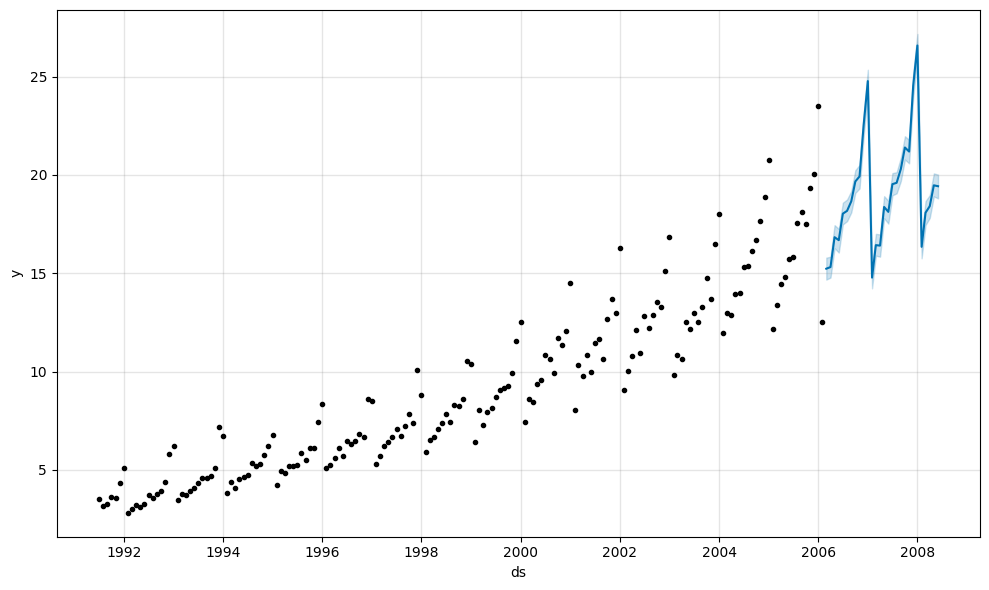

In [ ]:
# Build-it plot
model.plot(forecast_test);

In [ ]:
# Predict the next 48 datapoints
future = model.make_future_dataframe(periods=48, freq='MS')
forecast_future = model.predict(future)
forecast_future.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yearly,yearly_lower,yearly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat
0,1991-07-01,3.267868,2.666842,3.823488,3.267868,3.267868,-0.012944,-0.012944,-0.012944,-0.012944,-0.012944,-0.012944,0.0,0.0,0.0,3.225570
1,1991-08-01,3.321453,2.727773,3.854017,3.321453,3.321453,-0.015896,-0.015896,-0.015896,-0.015896,-0.015896,-0.015896,0.0,0.0,0.0,3.268655
2,1991-09-01,3.375039,2.837072,3.957150,3.375039,3.375039,0.012750,0.012750,0.012750,0.012750,0.012750,0.012750,0.0,0.0,0.0,3.418071
3,1991-10-01,3.426895,3.059877,4.204367,3.426895,3.426895,0.060714,0.060714,0.060714,0.060714,0.060714,0.060714,0.0,0.0,0.0,3.634958
4,1991-11-01,3.480481,3.062363,4.216334,3.480481,3.480481,0.043700,0.043700,0.043700,0.043700,0.043700,0.043700,0.0,0.0,0.0,3.632577


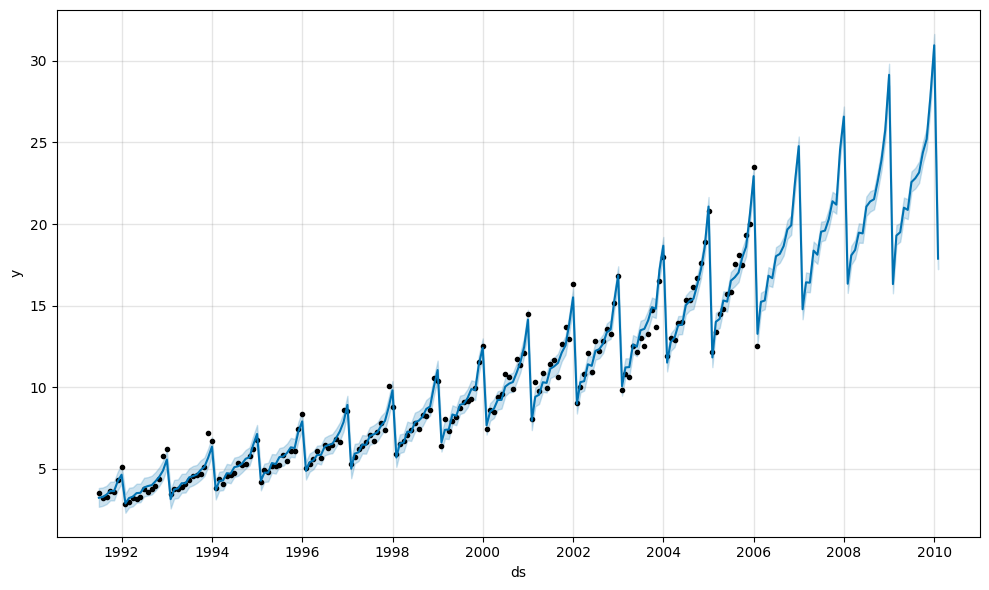

In [ ]:
# Build-it plot
model.plot(forecast_future);

### Cross-Validated Performance Metrics

- Facebook Prophet has its own cross-validation tool
- To use it,  we need to specify four parameters
    - the model
    - the prediction horizon (how much you want to predict/validation set size)
    - the initial values (size/time frame of training set)
    - the period (the spacing between cutoff dates for each cross-validation run)

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/cv-fb-prophet.png" width=400>

In [ ]:
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric

initial = f'{5 * 365} days' # needs to be in exactly this format
period = f'{5 * 365} days'
horizon = '365 days'
df_cv = cross_validation(model, initial=initial, period=period, horizon=horizon)

  0%|          | 0/2 [00:00<?, ?it/s]

18:10:03 - cmdstanpy - INFO - Chain [1] start processing
18:10:03 - cmdstanpy - INFO - Chain [1] done processing
18:10:03 - cmdstanpy - INFO - Chain [1] start processing
18:10:03 - cmdstanpy - INFO - Chain [1] done processing


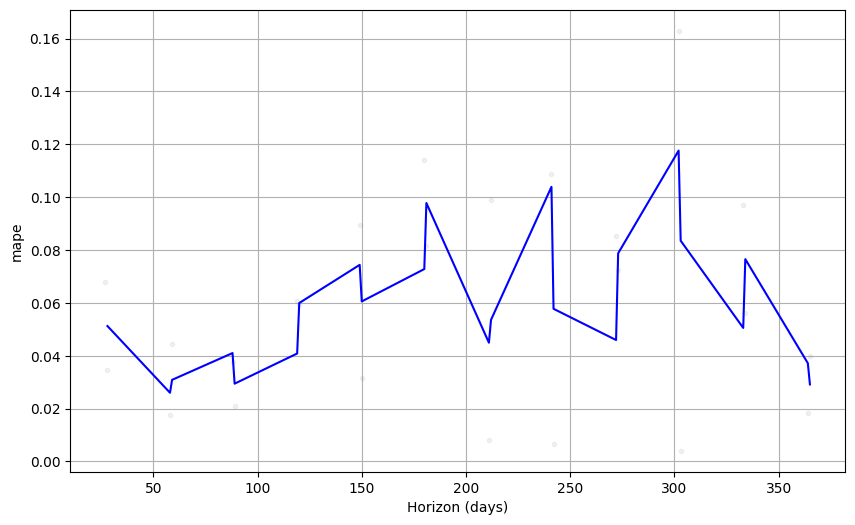

In [ ]:
plot_cross_validation_metric(df_cv, metric='mape');

## Bibliography
- [Time Series Analysis Blog (1/2 : concepts)](https://www.machinelearningplus.com/time-series/time-series-analysis-python/)
- [Time Series Analysis Blog (2/2 : arima models)](https://www.machinelearningplus.com/time-series/arima-model-time-series-forecasting-python/)

# 🚀 Your turn!